# **Creating and Fitting DNN Modeling**

**Importing Libraries & data:**

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import random
import tensorflow as tf
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.regularizers import l1,l2
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [14]:
symbol="BSE.NS"
df=pd.DataFrame(data=yf.download(tickers=symbol,period="1mo",interval="5m",auto_adjust=True)["Close"])
df["LR"]=np.log(df[symbol]/df[symbol].shift(1))
features=["Direction","SMA",'BB','rolling_min','rolling_max','momentum','Volatility']
sma_s=5;sma_l=30;sma_window=12
df[f"{features[0]}"]=np.where(df["LR"]>0,1,0)
df[f"{features[1]}"]=df[symbol].rolling(window=sma_s).mean()-df[symbol].rolling(window=sma_l).mean()
df[f"{features[2]}"]=(df[symbol]-df[symbol].rolling(window=sma_window).mean())/df[symbol].rolling(window=sma_window).std()
df[f"{features[3]}"]=df[symbol].rolling(window=sma_window).min()/(df[symbol]-1)
df[f"{features[4]}"]=df[symbol].rolling(window=sma_window).max()/(df[symbol]-1)
df[f"{features[5]}"]=df["LR"].rolling(window=sma_window).mean()
df[f"{features[6]}"]=df["LR"].rolling(window=sma_window).std()
df.dropna(inplace=True)
lags=7;cols=[]
for i in features:
  for j in range(1,lags+1):
    col=f"{i}_lag_{j}"
    df[col]=df[i].shift(periods=j)
    cols.append(col)
df.dropna(inplace=True);df

[*********************100%***********************]  1 of 1 completed


Ticker,BSE.NS,LR,Direction,SMA,BB,rolling_min,rolling_max,momentum,Volatility,Direction_lag_1,...,momentum_lag_5,momentum_lag_6,momentum_lag_7,Volatility_lag_1,Volatility_lag_2,Volatility_lag_3,Volatility_lag_4,Volatility_lag_5,Volatility_lag_6,Volatility_lag_7
Datetime,,,,,,,,,,,,,,,,,,,,,
2026-01-27 04:45:00+00:00,2737.000000,0.002597,1,27.133341,1.413480,0.971747,1.000365,0.001866,0.004276,1.0,...,0.000852,0.000673,0.000479,0.004365,0.004401,0.004387,0.004355,0.004187,0.004206,0.004215
2026-01-27 04:50:00+00:00,2746.800049,0.003574,1,33.600000,1.677766,0.974579,1.000364,0.002717,0.003345,1.0,...,0.000529,0.000852,0.000673,0.004276,0.004365,0.004401,0.004387,0.004355,0.004187,0.004206
2026-01-27 04:55:00+00:00,2736.899902,-0.003611,0,36.499976,1.074496,0.979641,1.003984,0.001875,0.003573,1.0,...,0.000920,0.000529,0.000852,0.003345,0.004276,0.004365,0.004401,0.004387,0.004355,0.004187
2026-01-27 05:00:00+00:00,2747.899902,0.004011,1,39.716634,1.549349,0.984601,1.000364,0.002079,0.003623,0.0,...,0.001193,0.000920,0.000529,0.003573,0.003345,0.004276,0.004365,0.004401,0.004387,0.004355
2026-01-27 05:05:00+00:00,2745.000000,-0.001056,0,40.726652,1.149406,0.985641,1.001421,0.001146,0.002678,1.0,...,0.001537,0.001193,0.000920,0.003623,0.003573,0.003345,0.004276,0.004365,0.004401,0.004387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-23 07:40:00+00:00,2727.199951,-0.001392,0,-6.956665,-1.378029,1.000367,1.006273,-0.000633,0.001203,0.0,...,-0.000198,-0.000107,-0.000186,0.001246,0.001250,0.001312,0.001204,0.001481,0.001339,0.001357
2026-02-23 07:45:00+00:00,2728.399902,0.000440,1,-7.216691,-1.016106,0.999927,1.005353,-0.000454,0.001188,0.0,...,-0.000420,-0.000198,-0.000107,0.001203,0.001246,0.001250,0.001312,0.001204,0.001481,0.001339
2026-02-23 07:50:00+00:00,2727.000000,-0.000513,0,-8.246704,-1.164744,1.000367,1.005613,-0.000457,0.001188,1.0,...,-0.000320,-0.000420,-0.000198,0.001188,0.001203,0.001246,0.001250,0.001312,0.001204,0.001481


In [15]:
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,:],df.iloc[:,0],train_size=0.75,random_state=42)
train_test=[x_train,x_test,y_train,y_test]
for i in train_test:
  print(f"shape = {i.shape}")
mu,std=x_train.mean(),x_train.std()
x_train_stand=(x_train-mu)/std
x_train_stand

shape = (1041, 58)
shape = (347, 58)
shape = (1041,)
shape = (347,)


Ticker,BSE.NS,LR,Direction,SMA,BB,rolling_min,rolling_max,momentum,Volatility,Direction_lag_1,...,momentum_lag_5,momentum_lag_6,momentum_lag_7,Volatility_lag_1,Volatility_lag_2,Volatility_lag_3,Volatility_lag_4,Volatility_lag_5,Volatility_lag_6,Volatility_lag_7
Datetime,,,,,,,,,,,,,,,,,,,,,
2026-02-04 07:10:00+00:00,-0.006088,-0.228313,-1.00048,1.388135,0.495491,-1.300598,-0.324372,1.235829,0.035867,1.049748,...,1.637355,1.720964,1.807977,0.010219,0.014145,-0.026141,-0.063330,-0.096822,-0.108795,-0.136359
2026-02-02 09:00:00+00:00,-1.506252,-0.167631,-1.00048,0.197079,0.578215,0.196754,-0.415706,0.100774,-0.230715,1.049748,...,-0.685383,-0.331042,-0.288411,-0.234146,-0.230660,-0.229328,-0.047470,-0.024481,0.146440,0.158586
2026-02-18 04:15:00+00:00,-0.568307,-0.106570,-1.00048,1.613658,0.533475,-2.028516,-0.001854,1.626920,0.561631,-0.951695,...,1.549964,1.520751,0.530903,0.570939,0.505655,0.443076,0.424992,0.449105,0.464937,-0.443972
2026-01-28 09:45:00+00:00,-0.387276,0.614229,0.99856,0.224367,1.670001,-0.283791,-0.496382,0.487967,-0.455368,1.049748,...,0.284226,0.372511,0.293672,-0.551565,-0.536897,-0.484705,-0.479866,-0.462215,-0.450923,-0.443171
2026-02-05 08:15:00+00:00,0.047196,0.087137,0.99856,0.507914,0.367034,-0.080759,-0.349042,0.381181,-0.364100,-0.951695,...,0.688429,0.735577,0.628420,-0.358518,-0.358212,-0.371035,-0.370709,-0.413045,-0.419364,-0.420831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-16 08:40:00+00:00,-0.500677,-0.045968,-1.00048,-0.013279,0.061550,0.428036,-0.372174,0.001510,-0.476853,-0.951695,...,-0.210890,-0.209029,0.212878,-0.475093,-0.464007,-0.480858,-0.448166,-0.420162,-0.419990,-0.158843
2026-02-17 05:20:00+00:00,-1.017128,-0.433850,-1.00048,-0.840495,-1.594878,0.639600,0.469629,-0.594182,-0.137915,-0.951695,...,0.050053,-0.595917,-0.682831,-0.124548,-0.153252,-0.200933,-0.175392,-0.176618,-0.045808,-0.046845
2026-02-19 06:30:00+00:00,-0.808772,-0.436725,-1.00048,-0.430022,-1.677536,0.639113,0.048108,-0.484495,-0.473322,1.049748,...,-0.223360,-0.330149,-0.314966,-0.506086,-0.513244,-0.523961,-0.518171,-0.490537,-0.457173,-0.455721


**Creating DNN model:**

In [16]:
def set_seeds(seed=100):
  random.seed(seed);np.random.seed(seed)
  tf.random.set_seed(seed)

def class_weight(df):
  c0,c1=np.bincount(df['Direction'])
  w0=(1/c0)*(len(df))/2
  w1=(1/c1)*(len(df))/2
  return {0:w0,1:w1}
optimizer=Adam(learning_rate=0.0001)
def create_model(hl=2,hu=100,dropout=False,rate=0.3,regularize=False,reg=l1(0.0005),optimizer=optimizer,input_dim=None):
  if not regularize:
    reg=None
  model=Sequential()
  model.add(Dense(hu,input_shape=(input_dim,),activity_regularizer=reg,activation="relu"))
  if dropout:
    model.add(Dropout(rate,seed=100))
  for layer in range(hl):
    model.add(Dense(hu,activation="relu",activity_regularizer=reg))
    if dropout:
      model.add(Dropout(rate,seed=100))
  model.add(Dense(1,activation="sigmoid"))
  model.compile(loss="binary_crossentropy",optimizer=optimizer,metrics=["accuracy"])
  return model

**Fitting DNN model:**

In [17]:
set_seeds(seed=100)
model=create_model(hl=3,hu=50,dropout=True,input_dim=len(cols))
model.fit(x=x_train_stand[cols],y=x_train['Direction'],epochs=50,verbose=False,class_weight=class_weight(x_train))
model.evaluate(x_train_stand[cols],x_train['Direction'])
pred=model.predict(x_train_stand[cols])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5804 - loss: 0.6830
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/tmp/ipython-input-2120581949.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.hist(pred,bins=50);plt.legend(fontsize=12)


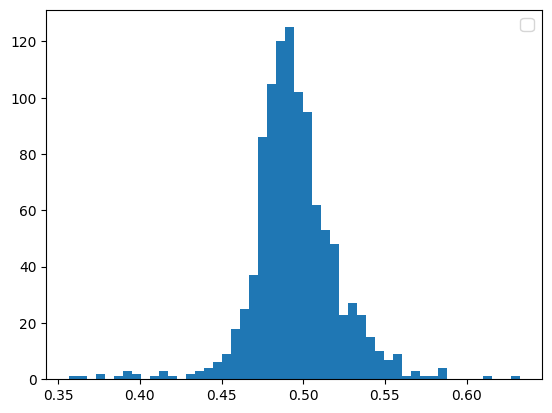

In [18]:
plt.hist(pred,bins=50);plt.legend(fontsize=12)
plt.show()